# Customer Churn Prediction + "Why They're Leaving" Explainer

**Goal:** Predict which customers are likely to churn, and explain *why* each customer is at risk using SHAP, so retention teams get both a prediction and an action plan.

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 features)

**Notebook sections:**
1. Setup & Imports
2. Data Loading & Overview
3. Exploratory Data Analysis (EDA)
4. Preprocessing & Feature Engineering
5. Baseline Model
6. Tuned Model (XGBoost) + Handling Class Imbalance
7. Model Evaluation
8. SHAP Explainability
9. Customer Segmentation (K-Means)
10. Export Artifacts for the Dashboard


## 1. Setup & Imports

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score
)
from sklearn.cluster import KMeans

import xgboost as xgb
from imblearn.over_sampling import SMOTE

import shap

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42

## 2. Data Loading & Overview

In [2]:
# Load the dataset
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Structural overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# TotalCharges is loaded as object (string) because of blank entries for new customers (tenure = 0).
# Convert to numeric, coercing blanks to NaN, then inspect.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing TotalCharges: {df['TotalCharges'].isna().sum()}")
df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Missing TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [5]:
# These are brand-new customers (tenure = 0), so TotalCharges is legitimately 0, not missing data.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop the customer ID - it's an identifier, not a feature
df.drop(columns=['customerID'], inplace=True)

# Check overall churn rate (our target class balance)
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis (EDA)

### 3.1 Churn by Contract Type
Contract type is typically the single strongest churn driver — let's confirm that here.

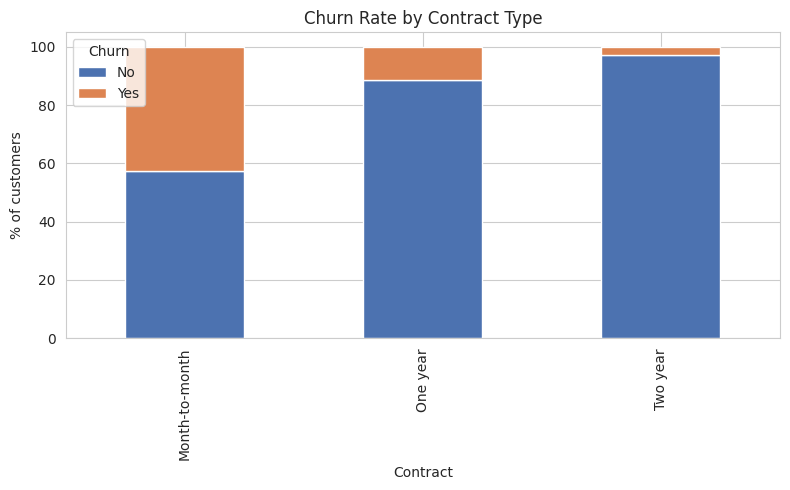

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [6]:
fig, ax = plt.subplots()
churn_by_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
churn_by_contract.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('% of customers')
ax.set_title('Churn Rate by Contract Type')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

print(churn_by_contract.round(1))

### 3.2 Churn by Tenure
Do customers churn early, or after a long relationship?

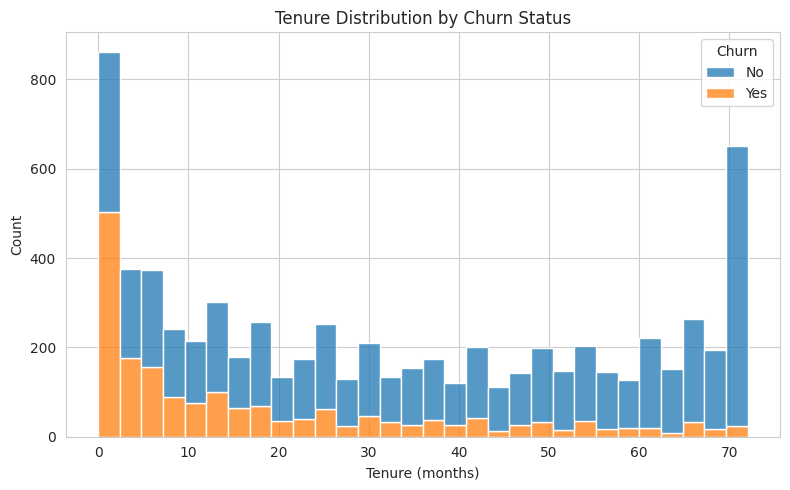

In [7]:
fig, ax = plt.subplots()
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='stack', ax=ax)
ax.set_title('Tenure Distribution by Churn Status')
ax.set_xlabel('Tenure (months)')
plt.tight_layout()
plt.show()

### 3.3 Churn by Monthly Charges

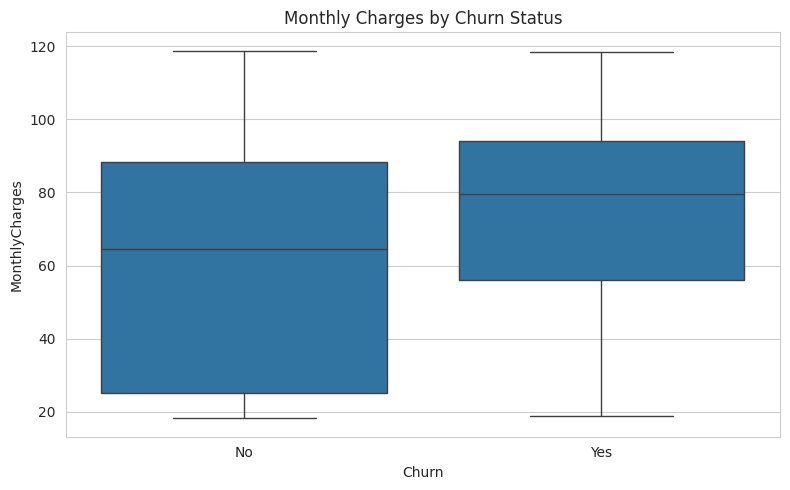

In [8]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax)
ax.set_title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.show()

### 3.4 Churn by Internet Service and Add-on Services
Customers without security/tech-support add-ons tend to churn more — worth checking.

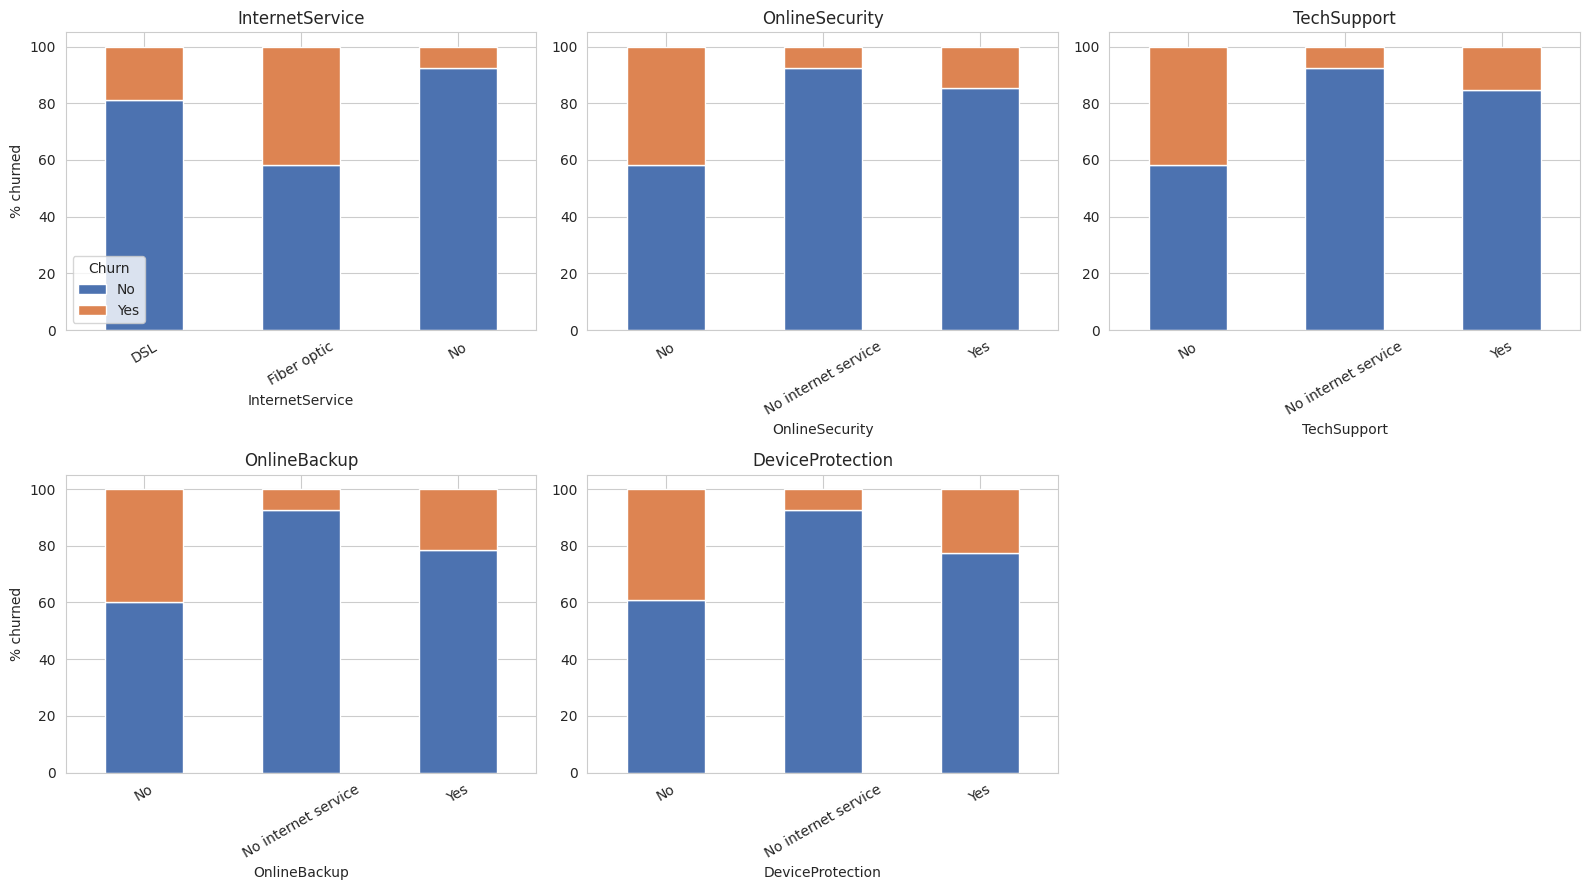

In [9]:
service_cols = ['InternetService', 'OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], legend=(i == 0), color=['#4C72B0', '#DD8452'])
    axes[i].set_title(col)
    axes[i].set_ylabel('% churned' if i % 3 == 0 else '')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### 3.5 Correlation Among Numeric Features

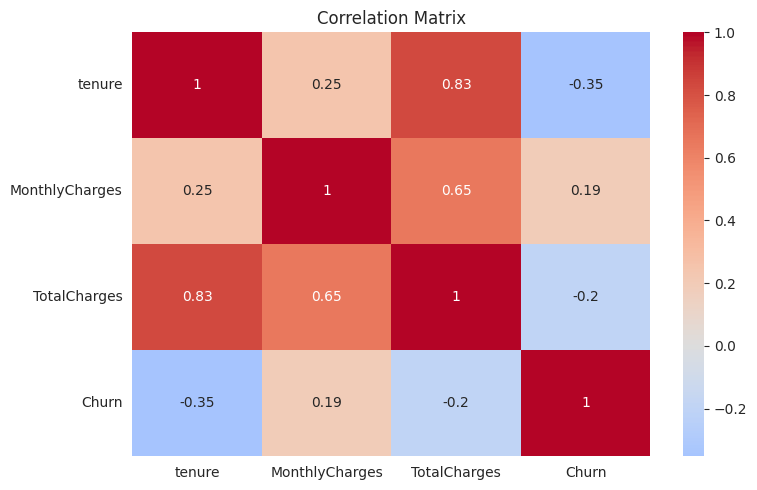

In [10]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

### EDA Summary

Key patterns to carry into modeling:
- **Contract type** is the strongest visible driver — month-to-month customers churn far more than one/two-year contracts.
- **Tenure** is inversely related to churn — early-tenure customers are highest risk.
- **Monthly charges** are higher among churners, suggesting price sensitivity.
- **Lack of add-on services** (online security, tech support) correlates with higher churn — customers without a "reason to stay" leave more easily.
- Class imbalance is present (~26% churn rate) — this will need to be addressed before modeling (Section 6).

## 4. Preprocessing & Feature Engineering

In [11]:
# Encode the target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Binary yes/no columns -> 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

df['gender'] = (df['gender'] == 'Male').astype(int)

# Columns with "No internet service" / "No phone service" are effectively "No" for churn purposes.
# Collapsing them avoids the model treating a 3rd category as meaningfully different from "No".
multi_cat_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in multi_cat_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# One-hot encode remaining categorical columns
cat_cols = ['InternetService', 'Contract', 'PaymentMethod'] + multi_cat_cols
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Shape after encoding: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_Yes,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
0,0,0,1,0,1,0,1,29.85,29.85,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,True,False,False,False,True,False,True,False,True,False,False,False
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,False,True,False,True,True,False,False,False,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,False,False,True,False,False,False,False,False,True,False,True,True,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,True,False,False,False,False,True,False,False,False,False,False,False,False,False


### Feature Engineering

Two engineered features that tend to add real predictive signal beyond the raw columns:
- **`avg_monthly_spend`**: TotalCharges / tenure — captures whether a customer is paying more or less than their MonthlyCharges rate suggests (useful for customers with billing changes).
- **`tenure_group`**: bucketed tenure — makes the strong early-tenure churn effect easier for tree models to split on cleanly.

In [12]:
# Average monthly spend (guard against division by zero for tenure=0)
df_encoded['avg_monthly_spend'] = df_encoded['TotalCharges'] / df_encoded['tenure'].replace(0, 1)

# Tenure buckets
df_encoded['tenure_group'] = pd.cut(
    df_encoded['tenure'], bins=[-1, 6, 12, 24, 48, 72],
    labels=['0-6mo', '7-12mo', '13-24mo', '25-48mo', '49-72mo']
)
df_encoded = pd.get_dummies(df_encoded, columns=['tenure_group'], drop_first=True)

print(f"Final feature count: {df_encoded.shape[1] - 1}")

Final feature count: 28


### Train/Test Split

In [13]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}")

Train: (5634, 28), Test: (1409, 28)
Train churn rate: 0.265, Test churn rate: 0.265


## 5. Baseline Model

We start with Logistic Regression as a baseline — it's simple, interpretable via coefficients, and gives us a floor to beat with the tuned model.

In [14]:
# Scale numeric features for Logistic Regression (tree models later won't need this)
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)

y_pred_base = baseline.predict(X_test_scaled)
y_proba_base = baseline.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_base))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_base):.3f}")

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.845


**Reading the baseline:** ROC-AUC in the 0.83-0.85 range is typical here, but recall on the churn class (1) is usually the weak point — the model is conservative about flagging churners because they're the minority class. That's exactly what Section 6 addresses with SMOTE and a tuned XGBoost model.

## 6. Tuned Model (XGBoost) + Handling Class Imbalance

Two things matter here:
- **Class imbalance**: use SMOTE — but critically, apply it *inside* each cross-validation fold via an `imblearn` Pipeline, not once on the whole training set beforehand. Applying SMOTE before CV lets synthetic neighbors of validation samples leak into the training folds, which inflates the CV score without improving real generalization (this is a common mistake in churn tutorials).
- **Model choice**: XGBoost handles the mixed categorical/numeric feature set well and pairs directly with SHAP for explainability.

In [15]:
from imblearn.pipeline import Pipeline as ImbPipeline

# SMOTE + XGBoost inside a single pipeline -> SMOTE is refit on each CV training fold only
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
])

param_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample': [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist, n_iter=20,
    scoring='roc_auc', cv=StratifiedKFold(5), random_state=RANDOM_STATE, n_jobs=-1
)
search.fit(X_train, y_train)  # raw, un-resampled training data - SMOTE happens inside each fold

print(f"Best params: {search.best_params_}")
print(f"Best CV ROC-AUC (leak-free): {search.best_score_:.3f}")

model = search.best_estimator_

Best params: {'clf__subsample': 0.8, 'clf__n_estimators': 200, 'clf__max_depth': 5, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.7}
Best CV ROC-AUC (leak-free): 0.837


In [16]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.52      0.71      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.75      0.76      1409

Test ROC-AUC: 0.835


## 7. Model Evaluation

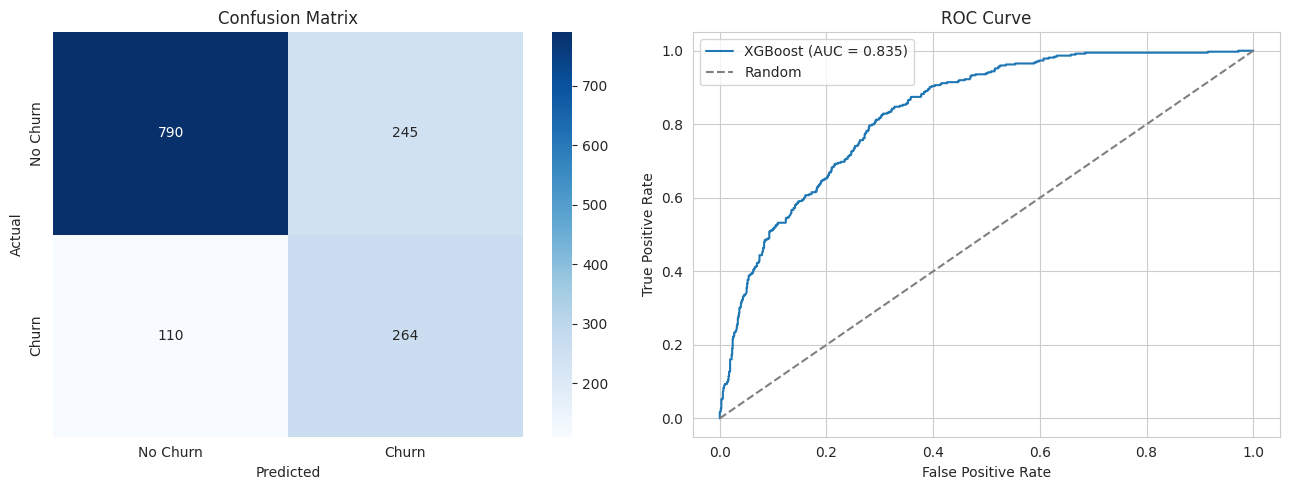

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba):.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

### Business-Aware Threshold Tuning

The default 0.5 classification threshold isn't necessarily right for a churn use case: missing a churner (false negative) usually costs a business far more than a wasted retention offer to a customer who wasn't going to churn (false positive). We can lower the threshold to trade some precision for recall, aligned with that cost asymmetry.

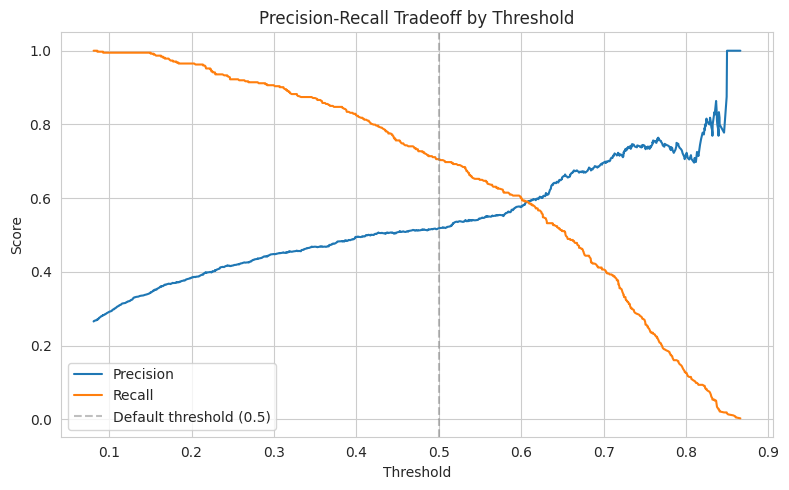

At threshold=0.35:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1035
           1       0.47      0.87      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.76      0.68      1409
weighted avg       0.81      0.70      0.72      1409



In [18]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots()
ax.plot(thresholds, precisions[:-1], label='Precision')
ax.plot(thresholds, recalls[:-1], label='Recall')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall Tradeoff by Threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Example: a lower threshold to prioritize catching more churners
custom_threshold = 0.35
y_pred_custom = (y_proba >= custom_threshold).astype(int)
print(f"At threshold={custom_threshold}:")
print(classification_report(y_test, y_pred_custom))

## 8. SHAP Explainability

This is the "why they're leaving" part. Instead of just a churn probability, SHAP tells us *which features pushed each customer's prediction up or down* — global patterns across all customers, and individual explanations per customer.

In [19]:
# Extract the fitted XGBoost model from the pipeline for SHAP
xgb_model = model.named_steps['clf']

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

### 8.1 Global Feature Importance
Which features drive churn predictions across the whole customer base?

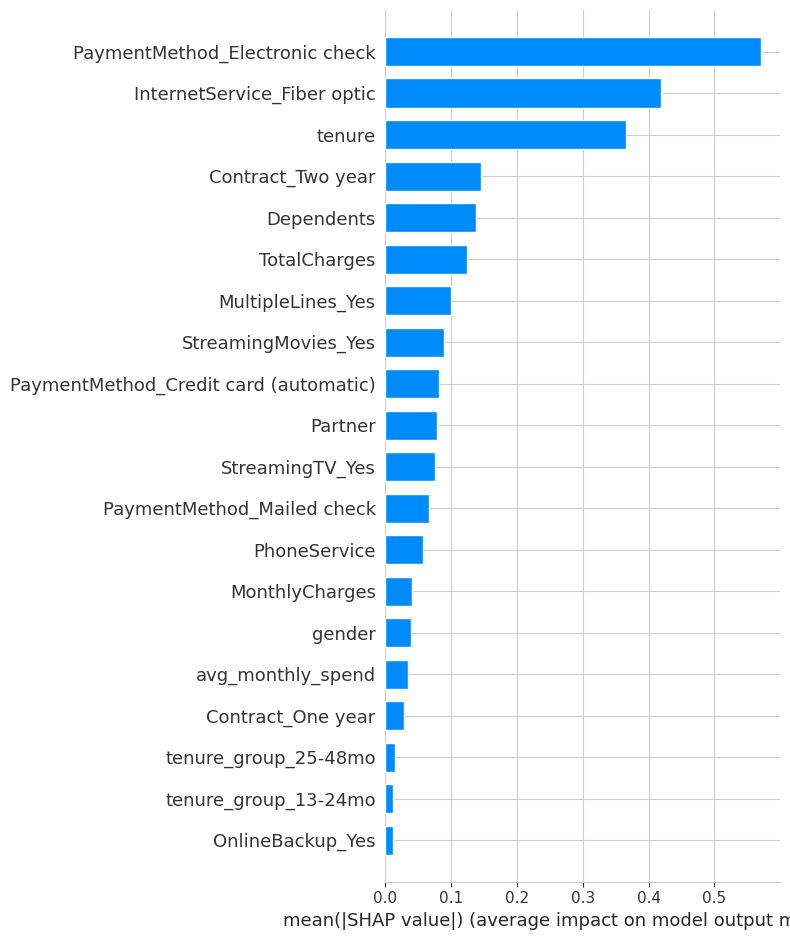

In [20]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

### 8.2 Direction of Effect
The beeswarm plot shows not just importance, but which direction each feature pushes risk.

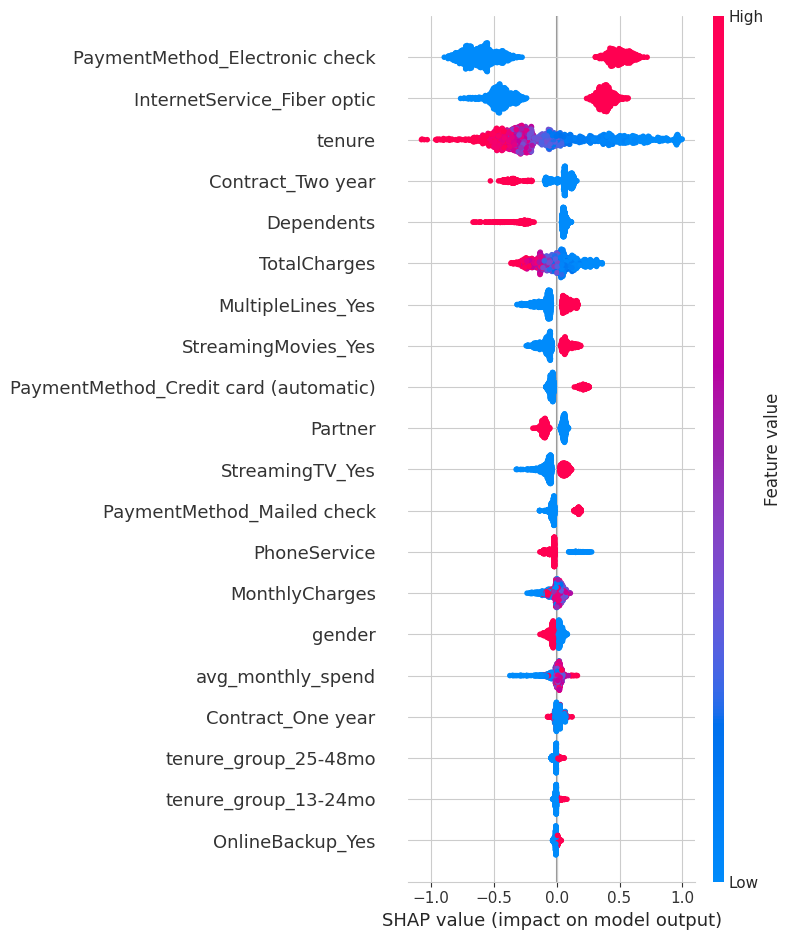

In [21]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

### 8.3 Per-Customer Explanation

This is what makes the model actionable: for any individual at-risk customer, we can show a retention agent *exactly* why the model flagged them, in plain terms.

In [22]:
def explain_customer(idx):
    """Show the top factors driving one customer's churn risk."""
    customer_shap = shap_values[idx]
    proba = y_proba[idx]

    top_idx = np.argsort(np.abs(customer_shap))[::-1][:5]
    print(f"Customer #{X_test.index[idx]} — Predicted churn probability: {proba:.1%}\n")
    print("Top factors driving this prediction:")
    for i in top_idx:
        feature = X_test.columns[i]
        value = X_test.iloc[idx][feature]
        effect = customer_shap[i]
        direction = "increases" if effect > 0 else "decreases"
        print(f"  - {feature} = {value}  ->  {direction} churn risk (impact: {effect:+.3f})")

# Pick the highest-risk customer in the test set as an example
highest_risk_idx = np.argmax(y_proba)
explain_customer(highest_risk_idx)

Customer #3727 — Predicted churn probability: 86.6%

Top factors driving this prediction:
  - PaymentMethod_Electronic check = True  ->  increases churn risk (impact: +0.458)
  - InternetService_Fiber optic = True  ->  increases churn risk (impact: +0.407)
  - tenure = 3  ->  increases churn risk (impact: +0.368)
  - MultipleLines_Yes = True  ->  increases churn risk (impact: +0.161)
  - TotalCharges = 291.9  ->  increases churn risk (impact: +0.122)


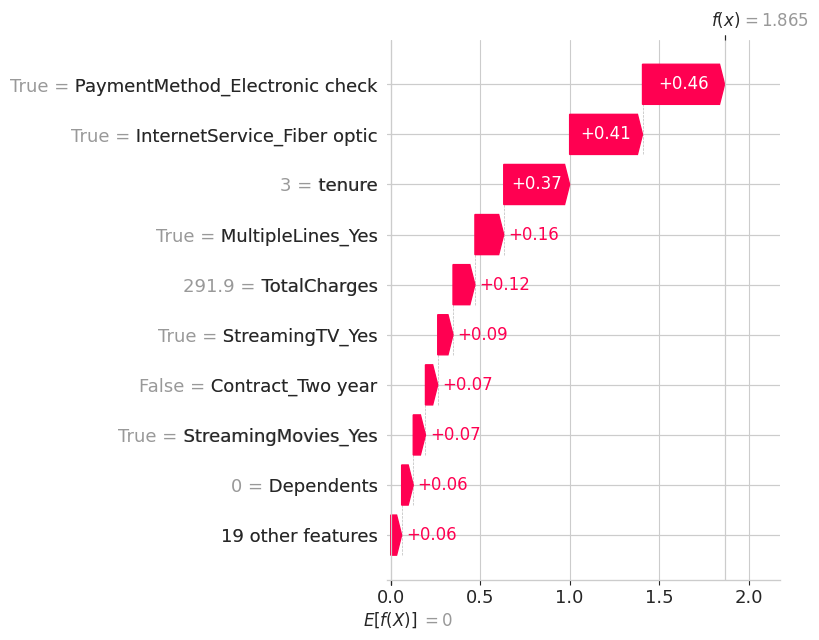

In [23]:
# Waterfall plot for the same customer - the visual version of the explanation above
shap.plots.waterfall(
    shap.Explanation(values=shap_values[highest_risk_idx],
                      base_values=explainer.expected_value,
                      data=X_test.iloc[highest_risk_idx],
                      feature_names=X_test.columns.tolist()),
    show=False
)
plt.tight_layout()
plt.show()

## 9. Customer Segmentation (K-Means)

Beyond individual predictions, retention teams think in segments. We cluster customers on churn-relevant behavioral features so each segment can get a tailored retention strategy, rather than a one-size-fits-all offer.

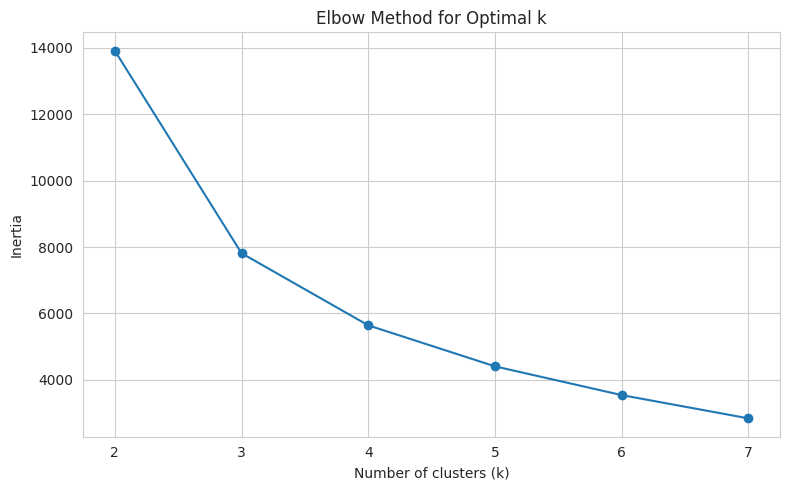

In [24]:
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend']
X_cluster = df_encoded[cluster_features].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Elbow method to choose k
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(k_range), inertias, marker='o')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k')
plt.tight_layout()
plt.show()

In [25]:
# k=4 balances interpretability with cluster separation for this feature set
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df_encoded['segment'] = kmeans.fit_predict(X_cluster_scaled)

segment_profile = df_encoded.groupby('segment').agg(
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    churn_rate=('Churn', 'mean'),
    size=('Churn', 'count')
).round(2)

segment_profile

,avg_tenure,avg_monthly_charges,churn_rate,size
segment,,,,
0,54.80,34.98,0.05,1116
1,15.41,80.22,0.48,2297
2,59.09,93.78,0.16,1906
3,10.92,31.36,0.24,1724


**Interpreting segments:** label each cluster by its profile once you see the numbers above — typically something like *"new high-spenders"* (short tenure, high charges, high churn — the priority retention target), *"loyal low-spenders"* (long tenure, low charges, low churn), *"established high-value"* (long tenure, high charges, low churn — protect these), and *"at-risk budget"* (short tenure, low charges, moderate churn). Update the labels below to match what your own cluster output shows.

## 10. Export Artifacts for the Dashboard

In [26]:
import joblib

# Save the trained pipeline (SMOTE + XGBoost) and the SHAP explainer
joblib.dump(model, '../app/churn_model.pkl')
joblib.dump(explainer, '../app/shap_explainer.pkl')

# Save the feature-engineered test set + predictions for the dashboard to load directly
export_df = X_test.copy()
export_df['actual_churn'] = y_test.values
export_df['predicted_proba'] = y_proba
export_df['segment'] = df_encoded.loc[X_test.index, 'segment'].values
export_df.to_csv('../app/scored_customers.csv', index=False)

print("Artifacts saved to ../app/")
print(f"  - churn_model.pkl ({X_test.shape[1]} features)")
print(f"  - shap_explainer.pkl")
print(f"  - scored_customers.csv ({len(export_df)} rows)")

Artifacts saved to ../app/
  - churn_model.pkl (28 features)
  - shap_explainer.pkl
  - scored_customers.csv (1409 rows)
